# 🎵 Spotify Analytics — API Deep Dive

A walkthrough of `spotify_analytics.py` — fetching metadata, building network graphs, predicting popularity, and more.

| Module | Function | Endpoint | Status |
|---|---|---|---|
| Track Metadata | `fetch_track_metadata()` | `/tracks`, `/artists`, `/albums` | ✅ Available |
| Network Graph | `build_artist_network()` | `/artists/{id}/related-artists` | 🔒 Restricted → fallback |
| Popularity Model | `train_popularity_model()` | `/tracks`, `/artists`, `/albums` | ✅ Available |
| Audio Analysis | `analyze_track_structure()` | `/audio-analysis/{id}` | 🔒 Restricted |
| User Top Items | `build_listening_dashboard()` | `/me/top/{type}` | ✅ Needs OAuth |
| Recommendations | `benchmark_recommendations()` | `/recommendations` | 🔒 Restricted → fallback |

---
## Setup

In [9]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))

from spotify_config import get_client_credentials_spotify, get_user_spotify
from spotify_analytics import (
    fetch_track_metadata, fetch_batch_metadata, display_track_card,
    build_artist_network, visualize_network,
    build_popularity_dataset, train_popularity_model,
    fetch_user_top_items, build_listening_dashboard,
)


import pandas as pd
import matplotlib.pyplot as plt

# Authenticate (no login needed — uses Client Credentials flow)
sp = get_client_credentials_spotify()
print("✅ Ready to go!")

✅ Ready to go!


---
## Module 1 — Track Metadata

**What it does:** Pulls enriched metadata for a single track by combining 3 API calls:
- `GET /tracks/{id}` → name, popularity, duration, explicit
- `GET /artists/{id}` → genres, followers, artist popularity
- `GET /albums/{id}` → release date, label, album popularity

Returns a flat dictionary with **28 fields** — ready for DataFrames or display.

### Single track — pretty card

In [10]:
# "Madness" by Muse
madness = fetch_track_metadata("53iuhJlwXhSER5J2IYYv1W", sp=sp)
display_track_card(madness)

┌─────────────────────────────────────────────────┐
│ 🎵  The Fate of Ophelia                         │
├─────────────────────────────────────────────────┤
│  Artist     │ Taylor Swift                     │
│  Album      │ The Life of a Showgirl           │
│  Popularity │ ███████████████████ 97/100│
│  Explicit   │ No  ✅                            │
│  Duration   │ 3:46                            │
│  Released   │ 2025-10-03                       │
│  Followers  │  155,031,543                   │
└─────────────────────────────────────────────────┘


### Inspect the raw dictionary

Every field that `fetch_track_metadata()` returns — useful for feature engineering later.

In [11]:
# See all 28 fields
for key, val in madness.items():
    print(f"  {key:.<30} {val}")

  track_id...................... 53iuhJlwXhSER5J2IYYv1W
  track_name.................... The Fate of Ophelia
  track_popularity.............. 97
  explicit...................... False
  duration_ms................... 226073
  disc_number................... 1
  track_number.................. 1
  is_local...................... False
  preview_url................... None
  external_url.................. https://open.spotify.com/track/53iuhJlwXhSER5J2IYYv1W
  isrc.......................... USUG12506436
  artist_names.................. Taylor Swift
  artist_ids.................... 06HL4z0CvFAxyc27GXpf02
  num_artists................... 1
  primary_artist_id............. 06HL4z0CvFAxyc27GXpf02
  primary_artist_name........... Taylor Swift
  artist_popularity............. 97
  artist_followers.............. 155031543
  artist_genres................. 
  num_genres.................... 0
  album_id...................... 4a6NzYL1YHRUgx9e3YZI6I
  album_name.................... The Life of a Showgi

### Try a few more tracks

In [12]:
# Pick any tracks you like — just swap in Spotify track IDs
# (Right-click a track in Spotify → Share → Copy Spotify URI → grab the ID after "track:")

tracks_to_try = {
    "Bohemian Rhapsody": "4u7EnebtmKWzUH433cf5Qv",
    "Basket Case":   "6L89mwZXSOwYl76YXfX13s",
    "Figure It Out":     "6V0A3jkb9ntudO0kmcJ1xd",
}

for name, tid in tracks_to_try.items():
    print(f"\n{'═'*50}")
    rec = fetch_track_metadata(tid, sp=sp)
    display_track_card(rec)


══════════════════════════════════════════════════
┌─────────────────────────────────────────────────┐
│ 🎵  Bohemian Rhapsody - Remastered 2011         │
├─────────────────────────────────────────────────┤
│  Artist     │ Queen                            │
│  Album      │ A Night At The Opera (2011 Remas │
│  Popularity │ ████████████████ 84/100  │
│  Explicit   │ No  ✅                            │
│  Duration   │ 5:54                            │
│  Released   │ 1975-11-21                       │
│  Genres     │ classic rock, rock, glam rock    │
│  Followers  │   56,908,136                   │
└─────────────────────────────────────────────────┘

══════════════════════════════════════════════════
┌─────────────────────────────────────────────────┐
│ 🎵  Basket Case                                 │
├─────────────────────────────────────────────────┤
│  Artist     │ Green Day                        │
│  Album      │ Dookie                           │
│  Popularity │ █████████████████ 8

---
## Module 1b — Batch Metadata → DataFrame

`fetch_batch_metadata()` fetches a list of tracks and returns a **pandas DataFrame**.  
This is the foundation for the popularity model in Module 3.

In [13]:
# A curated list of 15 tracks across genres
sample_track_ids = [
    "0c4IEciLCDdXEhhKxj4ThA",  # Madness — Muse
    "4u7EnebtmKWzUH433cf5Qv",  # Bohemian Rhapsody — Queen
    "6L89mwZXSOwYl76YXfX13s",  # Basket Case — Green Day
    "3n3Ppam7vgaVa1iaRUc9Lp",  # Mr. Brightside — The Killers
    "5HCyWlXZPP0y6Gqq8TgA20",  # Hotel California — Eagles
    "7ouMYWpwJ422jRcDASZB7P",  # Knights of Cydonia — Muse
    "1mea3bSkSGXuIRvnydlB5b",  # Viva la Vida — Coldplay
    "2tpWsVSb9UEmDRxAl1zhX1",  # Somebody That I Used to Know — Gotye
    "6dGnYIeXmHdcikdzNNDMm2",  # Smells Like Teen Spirit — Nirvana
    "60nZcImufyMA1MKQY3dcCH",  # Hurt — Johnny Cash
    "3AJwUDP919kvQ9QcozQPxg",  # Savior — Rise Against
    "7BKLCZ1jbUBVqRi2FVlTVw",  # Closer — The Chainsmokers
    "0e7ipj03S05BNilyu5bRzt",  # Rockstar — Post Malone
    "1BxfuPKGuaTgP7aM0Bbdwr",  # Circles — Post Malone
    "2Fxmhks0bxGSBdJ92vM42m",  # bad guy — Billie Eilish
]

df = fetch_batch_metadata(sample_track_ids, sp=sp)
print(f"\n📋 DataFrame shape: {df.shape}")
df[["track_name", "primary_artist_name", "track_popularity", "artist_genres", "album_release_date"]].head(10)

   ✅ Fetched 15 tracks.

📋 DataFrame shape: (15, 30)


,track_name,primary_artist_name,track_popularity,artist_genres,album_release_date
0,Madness,Muse,72,"alternative rock, rock",2012-09-24
1,Bohemian Rhapsody - Remastered 2011,Queen,84,"classic rock, rock, glam rock",1975-11-21
2,Basket Case,Green Day,86,"punk, pop punk",1994-02-01
3,Mr. Brightside,The Killers,66,alternative rock,2004-06-15
4,STAY (with Justin Bieber),The Kid LAROI,82,,2021-07-09
5,Knights of Cydonia,Muse,72,"alternative rock, rock",2006-06-28
6,Viva La Vida,Coldplay,89,,2008-06-06
7,Counting Stars,OneRepublic,90,soft pop,2013-01-01
8,Here Comes The Sun - Remastered 2009,The Beatles,86,"classic rock, psychedelic rock",1969-09-26
9,"Happy - From ""Despicable Me 2""",Pharrell Williams,84,,2014-03-03


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_id              15 non-null     object 
 1   track_name            15 non-null     object 
 2   track_popularity      15 non-null     int64  
 3   explicit              15 non-null     bool   
 4   duration_ms           15 non-null     int64  
 5   disc_number           15 non-null     int64  
 6   track_number          15 non-null     int64  
 7   is_local              15 non-null     bool   
 8   preview_url           0 non-null      object 
 9   external_url          15 non-null     object 
 10  isrc                  15 non-null     object 
 11  artist_names          15 non-null     object 
 12  artist_ids            15 non-null     object 
 13  num_artists           15 non-null     int64  
 14  primary_artist_id     15 non-null     object 
 15  primary_artist_name   15 

In [15]:
# Quick stats
print("📊 Popularity Distribution")
print(df["track_popularity"].describe().round(1))

print(f"\n🔢 Columns available ({len(df.columns)}):")
for col in df.columns:
    print(f"   • {col}")

📊 Popularity Distribution
count    15.0
mean     83.4
std       7.7
min      66.0
25%      82.5
50%      84.0
75%      89.5
max      93.0
Name: track_popularity, dtype: float64

🔢 Columns available (30):
   • track_id
   • track_name
   • track_popularity
   • explicit
   • duration_ms
   • disc_number
   • track_number
   • is_local
   • preview_url
   • external_url
   • isrc
   • artist_names
   • artist_ids
   • num_artists
   • primary_artist_id
   • primary_artist_name
   • artist_popularity
   • artist_followers
   • artist_genres
   • num_genres
   • album_id
   • album_name
   • album_type
   • album_popularity
   • album_total_tracks
   • album_release_date
   • album_label
   • is_single
   • track_position_ratio
   • album_age_days


---
## Module 2 — Popularity Prediction Model

**What it does:** Trains a Random Forest regressor to predict `track_popularity` (0–100) using only metadata features — no audio features needed.

| Feature | Source |
|---|---|
| `duration_ms`, `explicit`, `track_number` | Track metadata |
| `artist_popularity`, `artist_followers`, `num_genres` | Artist metadata |
| `album_popularity`, `album_age_days`, `is_single` | Album metadata |
| `track_position_ratio`, `num_artists` | Derived |

> ⚠️ For a meaningful model, you need **50+ tracks**. We'll expand our sample here.

In [17]:
# Let's use Spotify Search to get a diverse sample of ~50 tracks
# across different genres and popularity levels

search_queries = [
    "genre:rock", "genre:pop", "genre:hip-hop", "genre:indie",
    "genre:electronic", "genre:country", "genre:r&b", "genre:metal",
    "genre:jazz", "genre:classical",
]

all_track_ids = set(sample_track_ids)  # start with our earlier 15

for query in search_queries:
    results = sp.search(q=query, type="track", limit=5)
    for t in results["tracks"]["items"]:
        all_track_ids.add(t["id"])

all_track_ids = list(all_track_ids)
print(f"📋 Total unique tracks to fetch: {len(all_track_ids)}")

📋 Total unique tracks to fetch: 64


In [22]:
# Build the modeling dataset (this takes ~1-2 min for 60+ tracks)
pop_df = build_popularity_dataset(all_track_ids, sp=sp)
pop_df[["artist_names","track_name", "track_popularity", "artist_popularity","album_name","album_type","artist_genres", "album_age_days"]].head(10)

📊 Building popularity dataset...
   ✅ Fetched 64 tracks.
   Features available: 13/13
   Rows: 64


,artist_names,track_name,track_popularity,artist_popularity,album_name,album_type,artist_genres,album_age_days
0,Djo,End of Beginning,98,82,DECIDE,album,,1303
1,Linkin Park,Numb,90,90,Meteora,album,"nu metal, rap metal, rock, alternative metal",8418
2,Green Day,Basket Case,86,83,Dookie,album,"punk, pop punk",11757
3,Skeeny,Льды Невы,0,0,Льды Невы,single,,771
4,Kidd Peko,Milky way,0,1,Pieces of the (You)niverse,album,,1781
5,Calvin Harris,Summer,87,87,Motion,album,edm,4180
6,Laufey,Lover Girl,77,83,Lover Girl,single,,290
7,Billie Eilish,bad guy,83,91,"WHEN WE ALL FALL ASLEEP, WHERE DO WE GO?",album,,2570
8,Radiohead,Creep,93,86,Pablo Honey,album,"art rock, alternative rock",12101
9,Olivia Dean,Man I Need,98,92,Man I Need,single,pop soul,239


In [20]:
pop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_id              64 non-null     object 
 1   track_name            64 non-null     object 
 2   track_popularity      64 non-null     int64  
 3   explicit              64 non-null     int64  
 4   duration_ms           64 non-null     int64  
 5   disc_number           64 non-null     int64  
 6   track_number          64 non-null     int64  
 7   is_local              64 non-null     bool   
 8   preview_url           0 non-null      object 
 9   external_url          64 non-null     object 
 10  isrc                  64 non-null     object 
 11  artist_names          64 non-null     object 
 12  artist_ids            64 non-null     object 
 13  num_artists           64 non-null     int64  
 14  primary_artist_id     64 non-null     object 
 15  primary_artist_name   64 


📈 Popularity Model Results
   MAE:  2.99
   R²:   0.732
   Train: 51 | Test: 13


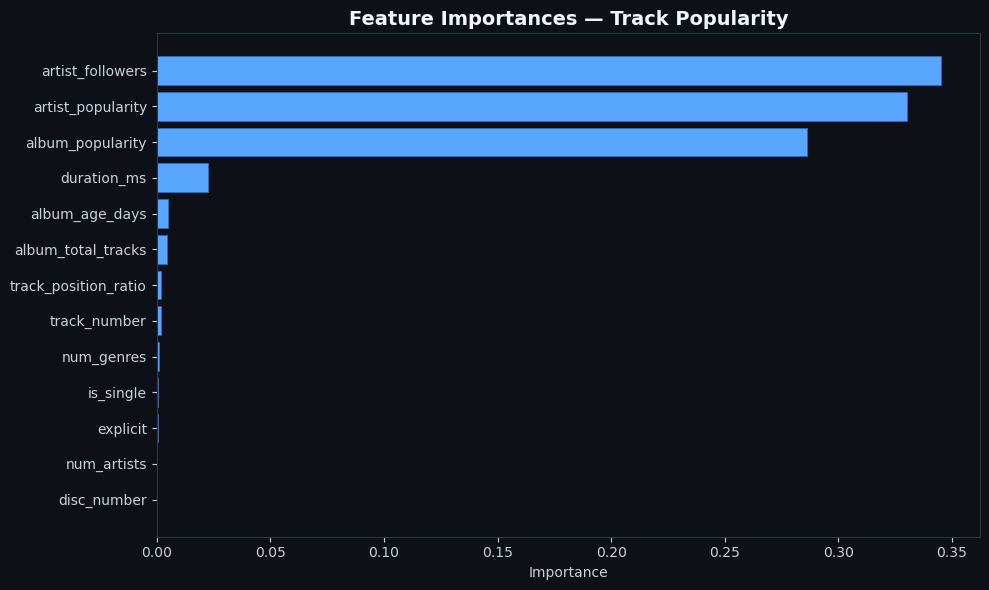

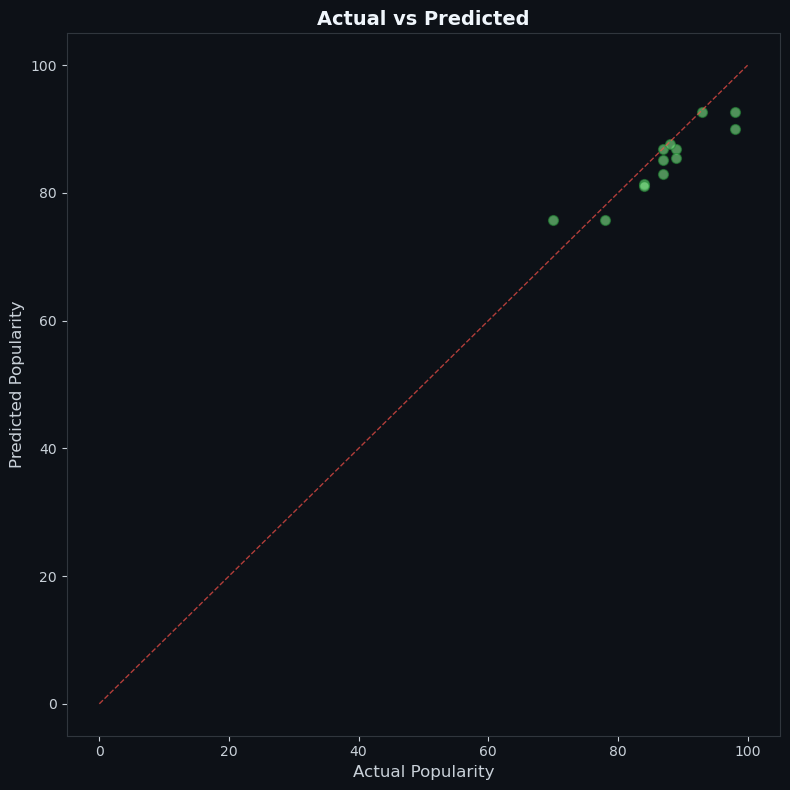

In [23]:
# Train the model
# Returns: model, MAE, R², feature importances, and two charts
results = train_popularity_model(pop_df)

In [24]:
# Model summary
if "error" not in results:
    print(f"📈 Model Performance")
    print(f"   MAE:  {results['mae']:.2f} (avg prediction error in popularity points)")
    print(f"   R²:   {results['r2']:.3f} (1.0 = perfect, 0.0 = baseline)")
    print(f"\n🏆 Top 5 Features:")
    for feat, imp in results["feature_importances"].sort_values(ascending=False).head(5).items():
        print(f"   {feat:<25} {imp:.3f}")

📈 Model Performance
   MAE:  2.99 (avg prediction error in popularity points)
   R²:   0.732 (1.0 = perfect, 0.0 = baseline)

🏆 Top 5 Features:
   artist_followers          0.345
   artist_popularity         0.330
   album_popularity          0.286
   duration_ms               0.023
   album_age_days            0.005


---
## Module 3 — User Top Items Dashboard (Needs OAuth)

**What it does:** Fetches YOUR top artists and tracks across 3 time ranges, then builds:
- Genre frequency charts per time range
- Popularity distribution histograms  
- Artist churn analysis (who appeared/disappeared)
- Listening diversity score

**Requires:** OAuth login (browser opens for Spotify authorization).  
Run the cell below to authenticate — it will open your browser.

In [26]:
# ⚠️ This will open your browser for Spotify login
# After you authorize, it caches the token so you only do this once

# Uncomment the lines below when ready:

sp_user = get_user_spotify()
print("✅ OAuth authenticated!")

✅ OAuth authenticated!


In [27]:
# Fetch just your top artists (medium term = last ~6 months)

# Uncomment when ready:
top_artists = fetch_user_top_items("artists", "medium_term", sp=sp_user)
top_artists.head(10)

   ✅ Fetched 50 top artists (medium_term)


,name,id,popularity,followers,genres,image_url,time_range
0,Muse,12Chz98pHFMPJEknJQMWvI,78,8752026,"alternative rock, rock",https://i.scdn.co/image/ab6761610000e5eb001bed...,medium_term
1,Rise Against,6Wr3hh341P84m3EI8qdn9O,71,3010031,"punk, hardcore punk",https://i.scdn.co/image/ab6761610000e5eb071291...,medium_term
2,Green Day,7oPftvlwr6VrsViSDV7fJY,83,18296592,"punk, pop punk",https://i.scdn.co/image/ab6761610000e5eb6ff0cd...,medium_term
3,Billy Talent,08yf5A2nS4XEeNvabDXqyg,65,1358946,punk,https://i.scdn.co/image/ab6761610000e5eb129c71...,medium_term
4,Fall Out Boy,4UXqAaa6dQYAk18Lv7PEgX,80,11720765,"emo, pop punk",https://i.scdn.co/image/ab6761610000e5eb362011...,medium_term
5,City and Colour,74gcBzlQza1bSfob90yRhR,55,907900,,https://i.scdn.co/image/ab6761610000e5eb6f6ab2...,medium_term
6,The Blue Stones,5VPCIIfZPK8KPsgz4jmOEC,56,249964,blues rock,https://i.scdn.co/image/ab6761610000e5eba0df2b...,medium_term
7,Linkin Park,6XyY86QOPPrYVGvF9ch6wz,90,34003142,"nu metal, rap metal, rock, alternative metal",https://i.scdn.co/image/ab6761610000e5eb527d95...,medium_term
8,Panic! At The Disco,20JZFwl6HVl6yg8a4H3ZqK,78,12980015,emo,https://i.scdn.co/image/ab6761610000e5ebb256ae...,medium_term
9,Twenty One Pilots,3YQKmKGau1PzlVlkL1iodx,85,26338331,,https://i.scdn.co/image/ab6761610000e5eb61a7ea...,medium_term


🎧 Building listening dashboard...

   ✅ Fetched 16 top artists (short_term)
   ✅ Fetched 50 top tracks (short_term)
   ✅ Fetched 50 top artists (medium_term)
   ✅ Fetched 50 top tracks (medium_term)
   ✅ Fetched 50 top artists (long_term)
   ✅ Fetched 50 top tracks (long_term)


c:\Users\jverc\OneDrive\Documents\GitHub\vercilloanalytics\projects\spotify\spotify_analytics.py:643: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
c:\Users\jverc\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127925 (\N{MUSICAL NOTE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


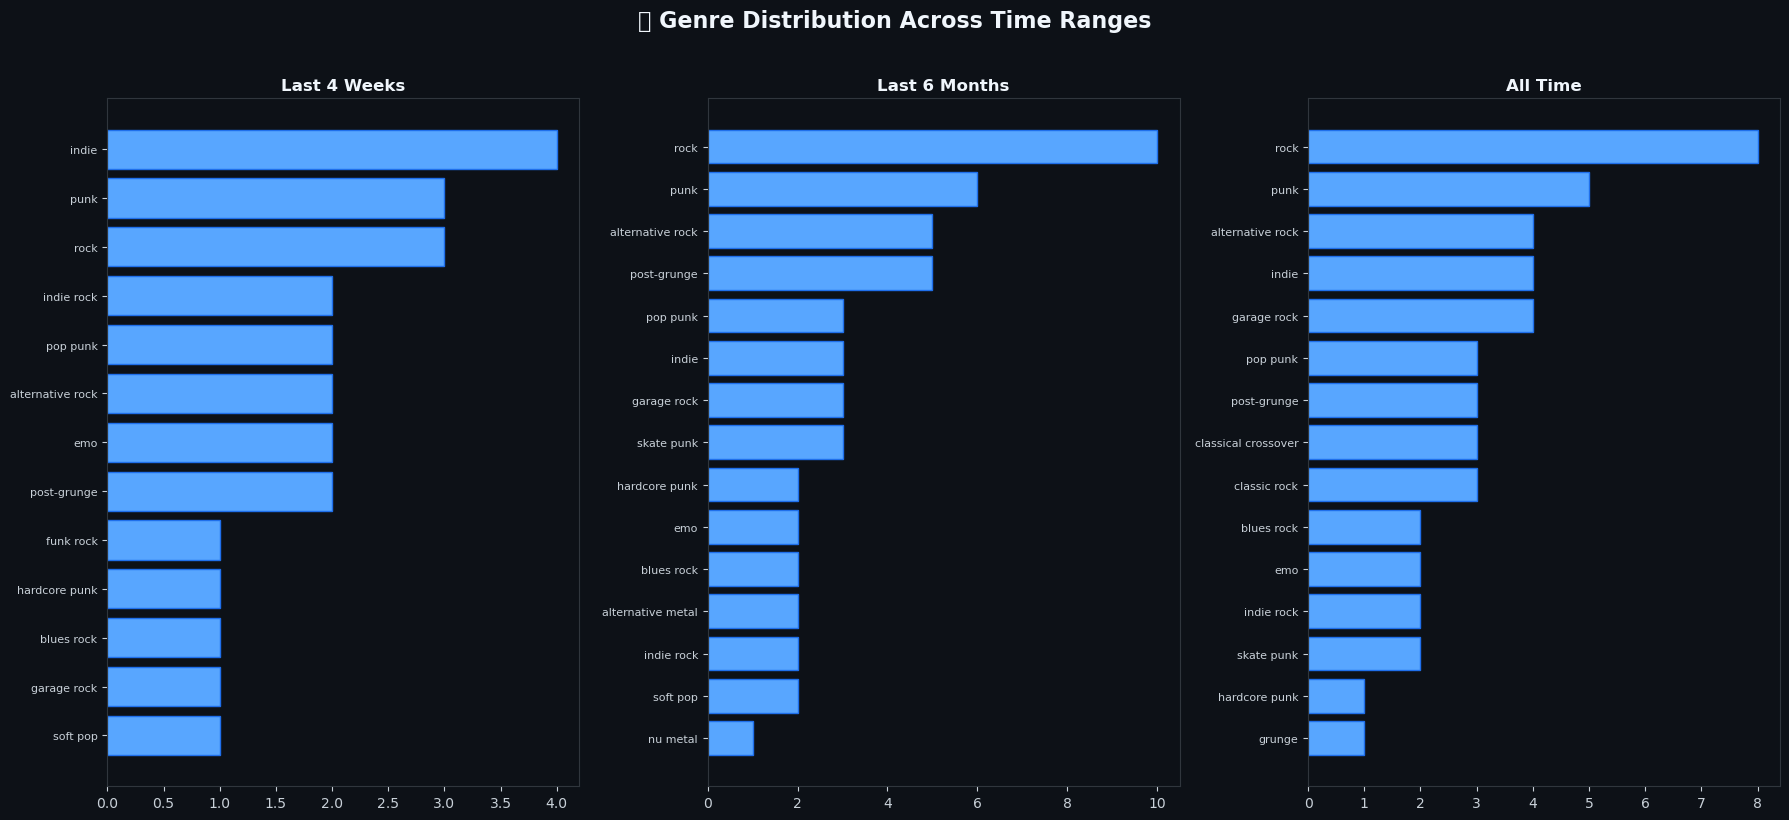

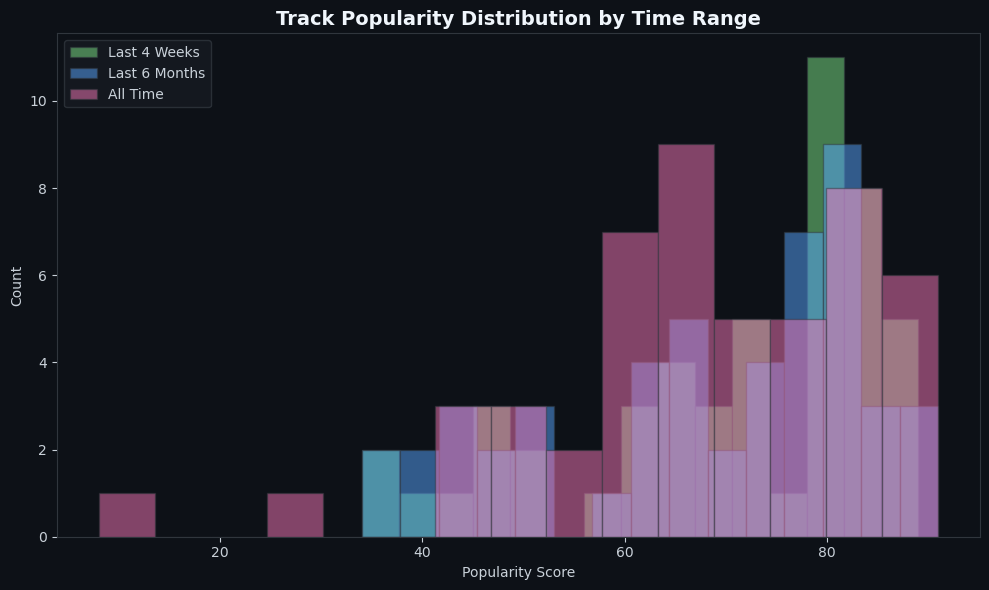


📊 Artist Churn Analysis
────────────────────────────────────────

   Last 4 Weeks vs Last 6 Months:
   Overlap: 14 artists
   New in Last 4 Weeks: 2
      → Wallows, Daughtry

   Last 6 Months vs All Time:
   Overlap: 37 artists
   New in Last 6 Months: 13
      → Shinedown, The Killers, July Talk, George Ezra, KONGOS...

🌈 Listening Diversity Scores
────────────────────────────────────────
   Last 4 Weeks: 13 genres / 16 artists = 0.81
   Last 6 Months: 30 genres / 50 artists = 0.60
   All Time: 39 genres / 50 artists = 0.78


In [28]:
# Full listening dashboard — all 3 time ranges with charts

# Uncomment when ready:
dashboard = build_listening_dashboard(sp=sp_user)

---
## 📖 API Quick Reference

### Available Endpoints (Client Credentials — no login)
```python
sp = get_client_credentials_spotify()

sp.track(track_id)              # Track metadata
sp.tracks([id1, id2, ...])      # Batch tracks (up to 50)
sp.artist(artist_id)            # Artist metadata
sp.artists([id1, id2, ...])     # Batch artists (up to 50)
sp.album(album_id)              # Album metadata + tracklist
sp.albums([id1, id2, ...])      # Batch albums (up to 20)
sp.search(q="query", type="track", limit=10)  # Search anything
sp.artist_top_tracks(artist_id) # Artist's top 10 tracks
sp.artist_albums(artist_id)     # Artist's discography
```

### Restricted Endpoints (need Extended Quota Mode)
```python
sp.audio_features(track_id)         # 🔒 Danceability, energy, valence, etc.
sp.audio_analysis(track_id)         # 🔒 Sections, segments, beats
sp.artist_related_artists(artist_id)# 🔒 Related artists
sp.recommendations(seed_artists=..) # 🔒 Track recommendations
```

### User Endpoints (need OAuth login)
```python
sp_user = get_user_spotify()  # Opens browser for login

sp_user.current_user_top_artists(limit=50, time_range="medium_term")
sp_user.current_user_top_tracks(limit=50, time_range="short_term")
```

### Function Signatures

```python
# ─── Track Metadata ───
fetch_track_metadata(track_id, sp=None) → dict         # Single track (28 fields)
fetch_batch_metadata(track_ids, sp=None) → DataFrame    # Batch → DataFrame
display_track_card(record)                              # Pretty-print a record

# ─── Network Graph ───
build_artist_network(seed_ids, sp=None, max_depth=2, max_nodes=80) → nx.Graph
visualize_network(G, title="...", figsize=(16,12))      # Dark-themed spring layout

# ─── Popularity Prediction ───
build_popularity_dataset(track_ids, sp=None) → DataFrame
train_popularity_model(df, target="track_popularity") → dict  # model, MAE, R², plots

# ─── Audio Analysis ───
analyze_track_structure(track_id, sp=None) → dict       # 🔒 restricted
visualize_audio_analysis(analysis, track_name)           # Song structure + loudness

# ─── User Top Items ───
fetch_user_top_items("artists"|"tracks", time_range, sp=None) → DataFrame
build_listening_dashboard(sp=None) → dict                # Full dashboard with charts

# ─── Recommendations ───
benchmark_recommendations(artist_ids, track_ids, sp=None) → dict
```

### How to Find Spotify IDs

| Method | Steps |
|---|---|
| Spotify Desktop | Right-click → Share → Copy link → ID is the last part after `/` |
| Spotify Web | Open track/artist → URL has the ID: `open.spotify.com/track/{ID}` |
| Search API | `sp.search(q="artist:Muse track:Madness", type="track")` |

Example:  
`https://open.spotify.com/track/0c4IEciLCDdXEhhKxj4ThA` → ID = `0c4IEciLCDdXEhhKxj4ThA`